# Day 11 of ML 30-Days Challenge

# Task

**Linear Regression**: Understand and implement your first regression model. Learn to interpret the model's coefficients to understand the relationship between each feature and the target variable, and check the model's underlying assumptions.

In [25]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

###1. Create Dataset

In [26]:
np.random.seed(42)

X = np.random.uniform(5, 50, 200).reshape(-1, 1)
noise = np.random.normal(0, 10, size=200)
y = 4.5 * X.flatten() + 20 + noise

nan_idx = np.random.choice(200, size=20, replace=False)
X[nan_idx] = np.nan

df = pd.DataFrame({'feature': X.flatten(), 'target': y})

df.describe()

,feature,target
count,180.000000,200.000000
mean,26.977458,141.185405
std,13.095050,60.268994
min,5.248495,35.038534
25%,15.758636,87.274670
50%,27.329572,137.167170
75%,38.204746,193.784507
max,49.409912,254.870866


###2. Impute Missing Values (SimpleImputer)

In [27]:
X = df[['feature']]
y = df['target']

imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

###3. Split into Train/Test (use 80/20 split)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=0
)

###4. Scale Features

In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

###5. Train Simple Linear Regression

In [30]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

###6. Make Predictions

In [31]:
y_pred = model.predict(X_test_scaled)

###7. Evaluate Model Performance

In [32]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R^2: {r2:.2f}")

Test RMSE: 15.49
Test R^2: 0.94


###8. (Optional) Visualize the Predictions

In [33]:
dfns = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

dfns.head()

,Actual,Predicted
18,121.073722,129.063278
170,171.524576,177.895640
107,203.245446,193.400440
98,35.038534,48.240572
177,127.097363,120.074999


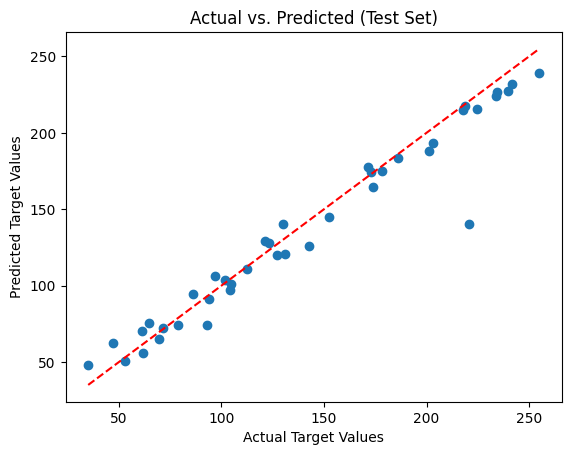

In [34]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Target Values')
plt.ylabel('Predicted Target Values')
plt.title('Actual vs. Predicted (Test Set)')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.show()